In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 500)

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
import seaborn as sns
rcParams['figure.figsize']=8,5

At the end of the notebook there should be models ready to deploy

In [4]:
# data_folder = '../data/processed/'
data_folder = '/kaggle/input/processed-data/'

In [5]:
!ls $data_folder

processed_test.csv  processed_train.csv


In [6]:
train_csv = 'processed_train.csv'
test_csv = 'processed_test.csv'
data_folder+train_csv, data_folder+test_csv

('/kaggle/input/processed-data/processed_train.csv',
 '/kaggle/input/processed-data/processed_test.csv')

# Exploring the datesets

In [7]:
train_df = pd.read_csv(data_folder+train_csv)
test_df = pd.read_csv(data_folder+test_csv)

train_df.shape, test_df.shape

((2000, 88), (500, 78))

In [8]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Component1_fraction,2000.0,8.171241e-17,1.000250,-1.107444,-0.923575,-0.249388,0.669958,1.957042
Component2_fraction,2000.0,-1.265654e-16,1.000250,-1.117602,-0.873197,-0.201084,0.715434,1.937458
Component3_fraction,2000.0,1.110223e-16,1.000250,-1.081681,-0.961374,-0.239531,0.662772,1.925996
Component4_fraction,2000.0,-2.930989e-17,1.000250,-2.353856,-0.865375,0.056066,1.119267,1.119267
Component5_fraction,2000.0,-9.769963e-17,1.000250,-1.427567,-0.804121,0.068704,0.816839,2.188421
max_fraction,2000.0,-9.459100e-16,1.000250,-3.332644,-0.619194,0.586783,0.737531,0.737531
min_fraction,2000.0,-1.865175e-17,1.000250,-0.649388,-0.649388,-0.649388,0.455483,4.322533
fraction_range,2000.0,2.930989e-16,1.000250,-4.262037,-0.536924,0.366133,0.817662,0.817662
Fraction1_Property1,2000.0,-1.865175e-17,1.000250,-5.633986,-0.285884,0.010562,0.329351,5.073571
Fraction1_Property2,2000.0,-3.463896e-17,1.000250,-4.985981,-0.303042,0.000357,0.284737,5.108260


In [9]:
num_col = list(train_df.describe().columns) 
num_col

['Component1_fraction',
 'Component2_fraction',
 'Component3_fraction',
 'Component4_fraction',
 'Component5_fraction',
 'max_fraction',
 'min_fraction',
 'fraction_range',
 'Fraction1_Property1',
 'Fraction1_Property2',
 'Fraction1_Property3',
 'Fraction1_Property4',
 'Fraction1_Property5',
 'Fraction1_Property6',
 'Fraction1_Property7',
 'Fraction1_Property8',
 'Fraction1_Property9',
 'Fraction1_Property10',
 'Fraction2_Property1',
 'Fraction2_Property2',
 'Fraction2_Property3',
 'Fraction2_Property4',
 'Fraction2_Property5',
 'Fraction2_Property6',
 'Fraction2_Property7',
 'Fraction2_Property8',
 'Fraction2_Property9',
 'Fraction2_Property10',
 'Fraction3_Property1',
 'Fraction3_Property2',
 'Fraction3_Property3',
 'Fraction3_Property4',
 'Fraction3_Property5',
 'Fraction3_Property6',
 'Fraction3_Property7',
 'Fraction3_Property8',
 'Fraction3_Property9',
 'Fraction3_Property10',
 'Fraction4_Property1',
 'Fraction4_Property2',
 'Fraction4_Property3',
 'Fraction4_Property4',
 'Fracti

# Splitting into training and validation dataset

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
data = train_df[num_col]

In [12]:
target_cols = [ col for col in num_col if "BlendProperty" in col ]
len(target_cols), target_cols

(10,
 ['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'])

In [13]:
X = data.drop(target_cols, axis=1)
y = data[target_cols]

In [14]:
val_size = 0.25 # trian = 75 % and val = 25 %
random_state = 42

In [15]:
X_train, X_val, y_train, y_val = train_test_split( \
            X, y, test_size=val_size, random_state=random_state
        )

In [16]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1500, 78), (500, 78), (1500, 10), (500, 10))

# Training

## Using baseline predictions

In [17]:
y_train.describe()

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.002434,0.004798,-0.031041,-0.007615,-0.032951,-0.017159,-0.029292,-0.004978,-0.000828,0.008489
std,0.998831,1.013191,1.001244,1.008583,0.968130,1.008985,1.003936,1.000045,0.989869,0.982309
min,-2.550897,-3.079759,-3.041624,-2.726882,-1.730111,-2.808210,-2.994571,-3.621080,-3.292727,-2.209607
25%,-0.737914,-0.719897,-0.670976,-0.797149,-0.693927,-0.712228,-0.668323,-0.714771,-0.682735,-0.723361
50%,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.112300,-0.001548,-0.007106,-0.002336
75%,0.756756,0.739762,0.696455,0.682796,0.337779,0.693553,0.673603,0.699638,0.690905,0.690500
max,2.856588,2.769156,1.638646,3.769643,3.507660,3.433292,3.293228,3.340657,3.276199,2.708703


### Fitting the baseline model

In [18]:
# y_train_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(y_train) for col in y_train}
# )

In [19]:
# print(y_train_pred.shape)  

In [20]:
# y_train_pred.head()

In [21]:
# y_val_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(y_val) for col in y_train} # median should be used from the traindataset
# )

In [22]:
# print(y_val_pred.shape)

In [23]:
# y_val_pred.describe()

## Other models

In [24]:
from sklearn.multioutput import MultiOutputRegressor

### Random Forest

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
# rf_basic = MultiOutputRegressor(RandomForestRegressor(
#                 n_estimators=100, random_state=42, n_jobs=-1
#             ))

In [27]:
# model_pkl_file = "random_forrest.pkl"  # to be used whlie saving hte model

### Fitting the other model

In [28]:
# # model = lr_basic
# model = rf_basic


In [29]:
# model.fit(X_train, y_train)

In [30]:
# y_train_pred = model.predict(X_train)
# y_val_pred = model.predict(X_val)

### Hyper-paramtric tuning

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
# Model selection and training
models = {
    # 'RandomForest': RandomForestRegressor(random_state=42),
    'MultiOutputRF': MultiOutputRegressor(RandomForestRegressor(random_state=42))
}

In [35]:
# Hyperparameter tuning for Random Forest
# rf_params = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# decreasing the search space
rf_params = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

In [36]:
# Train and evaluate models
results = {}
best_models = {}

In [37]:
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

In [38]:

class TqdmGridSearchCV(GridSearchCV):
    """
    Identical to GridSearchCV, but adds a tqdm progress bar that
    updates *after* each parameter combination finishes.
    """
    def _run_search(self, evaluate_candidates):
        candidates = list(self.param_grid.values())
        n_candidates = np.prod([len(v) for v in candidates])
        with tqdm(total=n_candidates, desc="Grid-search") as pbar:
            def wrapped_evaluate(cands):
                out = evaluate_candidates(cands)
                pbar.update(len(cands))
                return out
            super()._run_search(wrapped_evaluate)

In [39]:
# %time
# for name, model in models.items():
#     print(f"\nTraining {name}...")
    
#     if name == 'RandomForest':
#         # Direct multi-output Random Forest
#         grid_search = GridSearchCV(
#             model, rf_params, cv=5, 
#             scoring='neg_mean_absolute_percentage_error',
#             n_jobs=-1, verbose=1
#         )
#         grid_search.fit(X_train, y_train)
#         best_model = grid_search.best_estimator_
        
#     else:
#         # MultiOutputRegressor wrapper
#         inner_params = {f'estimator__{key}': value for key, value in rf_params.items()}
#         print(f'grid_search: started with \n {inner_params}')
#         grid_search = GridSearchCV(
#             model, inner_params, cv=5,
#             scoring='neg_mean_absolute_percentage_error',
#             n_jobs=-1, verbose=5
#         )
#         print('grid_search: Completed')
#         grid_search.fit(X_train, y_train)
#         best_model = grid_search.best_estimator_
    
#     best_models[name] = best_model
#     results[name] = grid_search.best_score_
#     print(f"Best CV score for {name}: {grid_search.best_score_:.4f}")

In [40]:
%time
print("Starting full training loop…")
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training model: {name}")
    print('='*60)

    if name == 'RandomForest':
        # direct multi-output
        params = rf_params
        gs = TqdmGridSearchCV(
            model,
            param_grid=params,
            cv=5,
            scoring='neg_mean_absolute_percentage_error',
            n_jobs=-1,
            refit=False,     # <- speeds up the search itself
            verbose=0        # <- we use tqdm instead
        )
    else:
        # MultiOutputRegressor wrapper
        params = {f'estimator__{k}': v for k, v in rf_params.items()}
        gs = TqdmGridSearchCV(
            model,
            param_grid=params,
            cv=5,
            scoring='neg_mean_absolute_percentage_error',
            n_jobs=-1,
            refit=False,
            verbose=0
        )

    print("GridSearch object created, starting .fit() …")
    gs.fit(X_train, y_train)
    print("GridSearch.fit() finished.")

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.34 µs
Starting full training loop…

Training model: MultiOutputRF
GridSearch object created, starting .fit() …


Grid-search: 100%|██████████| 16/16 [26:23<00:00, 98.98s/it]

GridSearch.fit() finished.


In [42]:
from sklearn.base import clone

In [43]:
%time
best_params = gs.best_params_
print("Best params:", best_params)
best_model = clone(model).set_params(**best_params)
best_model.fit(X_train, y_train)

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 6.2 µs
Best params: {'estimator__max_depth': 20, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}


MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=20,
                                                     min_samples_leaf=2,
                                                     n_estimators=200,
                                                     random_state=42))

In [44]:
# Select best model
best_models[name] = best_model
results[name] = gs.best_score_
print(f"Best CV score for {name}: {gs.best_score_:.4f}")

Best CV score for MultiOutputRF: -1.6565


# Saving trained model

In [45]:
import pickle

In [46]:
!pwd

/kaggle/working


In [47]:
# model_folder = '../models/'
model_folder = './kaggle/working/'

In [48]:
model_pkl_file = "rf_scaled_best_param.pkl"
model_pkl_file

'rf_scaled_best_param.pkl'

In [49]:
with open('./'+model_pkl_file, 'wb') as file:  
    pickle.dump(best_model, file)

##  Evaluation

In [59]:
# # Custom MAPE scorer for multi-output
# def multi_output_mape(y_true, y_pred):
#     """Calculate MAPE for each output and return mean"""
#     mapes = []
#     for i in range(y_true.shape[1]):
#         mape = mean_absolute_percentage_error(y_true[:, i], y_pred[:, i])
#         mapes.append(mape)
#     return np.mean(mapes)


In [62]:
# def evaluate_per_property(model, X, y, cv=5):
#     """Evaluate model performance per property"""
#     property_scores = {f'BlendProperty{i+1}': [] for i in range(y.shape[1])}
    
#     from sklearn.model_selection import KFold
#     kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    
#     for train_idx, val_idx in kfold.split(X):
#         X_train_fold, X_val_fold = X[train_idx], X[val_idx]
#         y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
#         model.fit(X_train_fold, y_train_fold)
#         y_pred_fold = model.predict(X_val_fold)
        
#         # Inverse transform predictions and targets
#         y_val_orig = target_scaler.inverse_transform(y_val_fold)
#         y_pred_orig = target_scaler.inverse_transform(y_pred_fold)
        
#         for i in range(y.shape[1]):
#             mape = mean_absolute_percentage_error(y_val_orig[:, i], y_pred_orig[:, i])
#             property_scores[f'BlendProperty{i+1}'].append(mape)
    
#     # Calculate mean and std for each property
#     property_results = {}
#     for prop, scores in property_scores.items():
#         property_results[prop] = {
#             'mean_mape': np.mean(scores),
#             'std_mape': np.std(scores)
#         }
    
#     return property_results

In [63]:
# best_model

{'estimator__max_depth': 20,
 'estimator__min_samples_leaf': 2,
 'estimator__min_samples_split': 2,
 'estimator__n_estimators': 200}

In [64]:
# # Evaluate per-property performance
# print("\nPer-property evaluation:")
# property_results = evaluate_per_property(best_model, X_train, y_train)

# for prop, metrics in property_results.items():
#     print(f"{prop}: MAPE = {metrics['mean_mape']:.4f} ± {metrics['std_mape']:.4f}")



Per-property evaluation:


KeyError: "None of [Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,\n       ...\n       1487, 1488, 1492, 1493, 1494, 1495, 1496, 1497, 1498, 1499],\n      dtype='int64', length=1200)] are in the [columns]"

## Competition related evaluation

In [50]:
model = best_model

In [51]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

In [52]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

In [53]:
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

In [54]:
print(f'train_r2: {round(train_r2,5)} ,\nval_r2: {round(val_r2,5)}  ,\ntrain_rmse:  {round(train_rmse,5)}  ,\nval_rmse: {round(val_rmse,5)}   ,\nval_mae: {round(val_mae*100,5)}  ')

train_r2: 0.98586 ,
val_r2: 0.91286  ,
train_rmse:  0.11882  ,
val_rmse: 0.29559   ,
val_mae: 22.06589  


The baseline vlaues are as below;
```
train_r2: -0.00975

val_r2: -0.01272

train_rmse: 1.00199

val_rmse: 1.01016

val_mae: 80.2424
```
These values doesn't make sense. Check what does these mean???

In [55]:
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_train_pct = mape_train * 100 # Converting decimals to percentage

In [56]:
# Printing results
print(f'Mean Absolute Percentage Error TRAIN = {mape_train_pct}%')

Mean Absolute Percentage Error TRAIN = 62.683792291065444%


In [57]:
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
mape_val_pct = mape_val * 100 # Converting decimals to percentage

In [58]:
# Printing results
print(f'Mean Absolute Percentage Error TRAIN = {mape_val_pct}%')

Mean Absolute Percentage Error TRAIN = 477.8606047284373%


# Leaderboard Score

In [59]:
cost = mape_val_pct
test_set = "public_testset"
if test_set=='public_testset':
    ref_cost = 2.72
elif test_set=='private_testset':
    ref_cost = 2.58
cost,ref_cost

(477.8606047284373, 2.72)

In [60]:
calulated_term = 100 - ((90 * cost)/ref_cost)
calulated_term

-15711.564127043881

In [61]:
leaderboardscore = max(10, calulated_term)

In [62]:
print(f'the score relevant to the competition is {leaderboardscore}')

the score relevant to the competition is 10


# Training selected model on whole train Data set

In [63]:
final_model = model
final_model

MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=20,
                                                     min_samples_leaf=2,
                                                     n_estimators=200,
                                                     random_state=42))

In [64]:
%time
final_model.fit(X, y)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 9.06 µs


MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=20,
                                                     min_samples_leaf=2,
                                                     n_estimators=200,
                                                     random_state=42))

# Inference

In [65]:
X_train.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'max_fraction',
       'min_fraction', 'fraction_range', 'Fraction1_Property1',
       'Fraction1_Property2', 'Fraction1_Property3', 'Fraction1_Property4',
       'Fraction1_Property5', 'Fraction1_Property6', 'Fraction1_Property7',
       'Fraction1_Property8', 'Fraction1_Property9', 'Fraction1_Property10',
       'Fraction2_Property1', 'Fraction2_Property2', 'Fraction2_Property3',
       'Fraction2_Property4', 'Fraction2_Property5', 'Fraction2_Property6',
       'Fraction2_Property7', 'Fraction2_Property8', 'Fraction2_Property9',
       'Fraction2_Property10', 'Fraction3_Property1', 'Fraction3_Property2',
       'Fraction3_Property3', 'Fraction3_Property4', 'Fraction3_Property5',
       'Fraction3_Property6', 'Fraction3_Property7', 'Fraction3_Property8',
       'Fraction3_Property9', 'Fraction3_Property10', 'Fraction4_Property1',
       'Fraction4_Property2'

In [66]:
len(target_cols),target_cols

(10,
 ['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'])

In [67]:
# test_num_col =  list(set(X_train.columns) - set(target_cols))
# len(test_num_col),test_num_col

In [68]:
X_test = test_df[X_train.columns]
X_test.shape

(500, 78)

## Loading the model

In [69]:
# filename = model_folder + model_pkl_file
filename = './'+model_pkl_file
filename


'./rf_scaled_best_param.pkl'

In [70]:
loaded_model = pickle.load(open(filename, 'rb'))

In [71]:
loaded_model

MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=20,
                                                     min_samples_leaf=2,
                                                     n_estimators=200,
                                                     random_state=42))

## using baseline predictions

In [72]:
# y_test_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(X_test) for col in y_train}
# )

In [73]:
# print(y_test_pred.shape)

## Using Random forest

In [74]:
y_test_pred = loaded_model.predict(X_test)

#  Preparing the submission file



In [76]:
pwd

'/kaggle/working'

In [77]:
# raw_test_df = pd.read_csv('../data/raw/test.csv')
# raw_test_df.shape

In [78]:
# test_df['ID'] =raw_test_df['ID']
test_df['ID'] = range(1, 501)

In [79]:
test_df[target_cols] = y_test_pred
test_df.shape

(500, 89)

In [80]:
test_df.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'max_fraction',
       'min_fraction', 'fraction_range', 'Fraction1_Property1',
       'Fraction1_Property2', 'Fraction1_Property3', 'Fraction1_Property4',
       'Fraction1_Property5', 'Fraction1_Property6', 'Fraction1_Property7',
       'Fraction1_Property8', 'Fraction1_Property9', 'Fraction1_Property10',
       'Fraction2_Property1', 'Fraction2_Property2', 'Fraction2_Property3',
       'Fraction2_Property4', 'Fraction2_Property5', 'Fraction2_Property6',
       'Fraction2_Property7', 'Fraction2_Property8', 'Fraction2_Property9',
       'Fraction2_Property10', 'Fraction3_Property1', 'Fraction3_Property2',
       'Fraction3_Property3', 'Fraction3_Property4', 'Fraction3_Property5',
       'Fraction3_Property6', 'Fraction3_Property7', 'Fraction3_Property8',
       'Fraction3_Property9', 'Fraction3_Property10', 'Fraction4_Property1',
       'Fraction4_Property2'

In [81]:
req_sub_cols = ['ID'] + target_cols
len(req_sub_cols)

11

In [82]:
test_df[req_sub_cols].head()

,ID,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,1,-0.253744,0.184414,0.613623,0.483049,0.186457,0.501046,0.528997,0.477845,-0.293304,0.470267
1,2,-0.597757,-0.381536,-1.222526,-0.050144,-0.750649,-0.051165,-1.209862,-1.271443,-0.176488,0.315657
2,3,1.309683,0.682037,0.716588,0.723890,2.238970,1.462351,0.701074,1.453632,0.082719,1.991649
3,4,0.019188,0.620210,0.634039,-0.307938,2.135142,-0.177279,0.692263,1.296122,0.762751,-0.580558
4,5,0.307325,-0.545588,1.170350,0.247096,2.420342,0.122684,1.167973,-0.373401,-0.669998,0.881628


<Axes: ylabel='Density'>

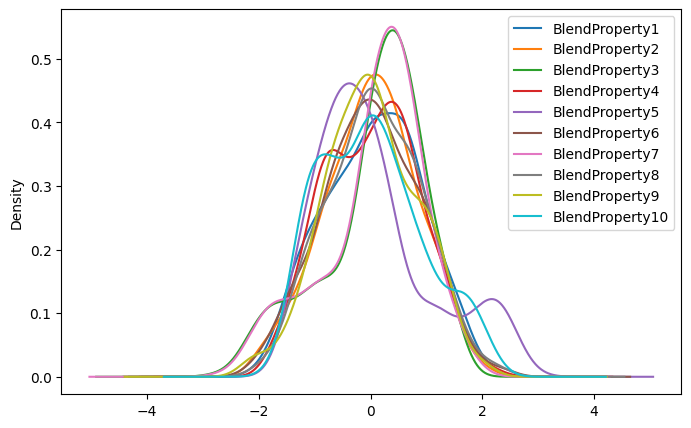

In [83]:
test_df[target_cols].plot.density()

In [91]:
# submission_folder = '../data/submission/'
submission_folder = './'

In [92]:
file_name = 'rf_multi_scaled_hyper_param'

In [93]:
test_df[req_sub_cols].to_csv(submission_folder+file_name+'.csv',index=False)